# ADEPT Architectural Analysis: Federated Learning System

This notebook exercises the ADEPT framework's real analysis methodology end to
end against the Federated Learning example: model summary (R4), an explicit
spec-linting sanity check (R1-R3), tradeoff definition, per-decision
contingency analysis for FL's 3 composed pattern decisions, key-parameter
selection via smart correlation with FL's policy-bound pattern parameters
included (R6), PRIM/CART scenario discovery (R9), and box-diagnostics
visualization including a best-effort search for an optional parameter's
"not selected" N/A-hatching state (R10).

It retires `federatedlearning/test_manual_simple.py`,
`federatedlearning/test_nan_feature.ipynb`, and root `test_nan_manual.py` as
the primary validation path (R11); those files remain in place, unmodified.

In [1]:
# Set project root in path so we can import 'adept' package
import sys
sys.path.append("..")

import itertools
import json
import pandas as pd
import matplotlib.pyplot as plt

from adept import PatternAnalysis
from adept.utils.linter import SystemLinter
from adept.utils.spec_summary import summarize_system
from adept.utils.nan_handler import SemanticNaNHandler

# Generic per-client aggregator preprocessor (U3) -- detects "Client <N> <field>"
# columns and aggregates them into the 6 uncertainty parameters (R7) and 2 of the
# 3 new telemetry quality objectives (R8) declared in FLsystem_split.json.
from preprocess_fl_clients import preprocess_fl

## 1. Load System & Model Summary (R4)

We initialize a `PatternAnalysis` session against FL's declarative system
definition and load the FL dataset through the `preprocess_fl` preprocessor
hook (U3). We then print the auto-generated model summary (`summarize_system`,
R4/U2) so the system's decisions, policies, parameter bindings, and
configuration coverage are visible before any analysis is built on top of it.

In [2]:
session = PatternAnalysis('./FLsystem_split.json')
session.load(preprocessor=preprocess_fl)

print(f"Loaded {len(session.raw_df)} experiments.")
print()
print(summarize_system(session.sys_def))

Loading single source file: ./FLwithAP_MLdata_split.csv
Loaded 32 rows.
Applying preprocessor hook to single file...
[WARNING] Dataspace.Configurations: Component 'fl_system' has incomplete policy-combination coverage: 4 of 8 combinations declared (decisions: client_selector_pattern, message_compressor_pattern, hdh_pattern). Missing combinations: OFF,ON,ON, ON,OFF,ON, ON,ON,OFF, ON,ON,ON.
[WARNING] Dataspace.QualityObjectives: Quality Objective 'RAM Usage Avg Mean' is low-variance: 78.1% of values are concentrated on a single value (threshold 70%).
[WARNING] System.Components: Parameter 'N Rounds' (Component: fl_system) is low-variance: 100.0% of values are concentrated on a single value (threshold 70%).
[WARNING] System.Components: Parameter 'Total Clients' (Component: fl_system) is low-variance: 100.0% of values are concentrated on a single value (threshold 70%).
[WARNING] System.Components: Parameter 'Dataset' (Component: fl_system) is low-variance: 100.0% of values are concentrated

## 2. Linter Sanity Check (R1-R3, U1)

Before building any analysis on top of the spec, we explicitly re-run
`SystemLinter` and inspect its findings. We lint against `session.raw_df`
(parameters + quality objectives combined) rather than `session.experiments_df`
(parameters only): `experiments_df` alone lacks the quality-objective columns
the linter checks for, which would otherwise misfire as 8 false "objective not
found" `ERROR`s. This matches how `GenericDataLoader.validate_data_integrity`
invokes the linter internally during `session.load()` (it lints the combined
raw dataframe, not the post-split experiments-only frame).

We expect zero `ERROR`s, one policy-combination coverage `WARNING` (4 of 8
combinations declared), and low-variance `WARNING`s on all 6 of FL's
aggregated client-heterogeneity parameters (R7) -- the notebook should not
proceed past a spec the linter would flag.

In [3]:
issues = SystemLinter().lint(session.sys_def, session.raw_df)
errors = [i for i in issues if i.level == "ERROR"]
warnings_ = [i for i in issues if i.level == "WARNING"]

print(f"Linter findings: {len(errors)} ERROR(s), {len(warnings_)} WARNING(s)")
for issue in issues:
    print(" ", issue)

assert not errors, f"Linter reported ERROR-level issues; fix the spec before proceeding: {errors}"

Linter findings: 0 ERROR(s), 25 WARNING(s)
  [WARNING] Dataspace.Configurations: Component 'fl_system' has incomplete policy-combination coverage: 4 of 8 combinations declared (decisions: client_selector_pattern, message_compressor_pattern, hdh_pattern). Missing combinations: OFF,ON,ON, ON,OFF,ON, ON,ON,OFF, ON,ON,ON.
  [WARNING] Dataspace.QualityObjectives: Quality Objective 'RAM Usage Avg Mean' is low-variance: 78.1% of values are concentrated on a single value (threshold 70%).
  [WARNING] System.Components: Parameter 'N Rounds' (Component: fl_system) is low-variance: 100.0% of values are concentrated on a single value (threshold 70%).
  [WARNING] System.Components: Parameter 'Total Clients' (Component: fl_system) is low-variance: 100.0% of values are concentrated on a single value (threshold 70%).
  [WARNING] System.Components: Parameter 'Dataset' (Component: fl_system) is low-variance: 100.0% of values are concentrated on a single value (threshold 70%).
  [WARNING] System.Component

## 3. Define Tradeoffs (R9)

FL declares 8 quality objectives (6 original + 2 new telemetry objectives from
R8), but only 32 experiment rows. Discretizing all 8 objectives combinatorially
(3 bins each = 3^8 = 6,561 possible tradeoffs) would be intractable and
meaningless at this sample size -- almost every combination would be empty.
We instead discretize FL's two headline objectives -- `best_val_f1` (model
quality) and `avg_total_time` (cost) -- into 3 bins each, mirroring the
Gateway Offloading notebook's use of a small, meaningful objective pair rather
than every declared outcome.

In [4]:
tradeoffs, schemes = session.create_tradeoffs(
    method='discretization', n_bins=3,
    objectives=['best_val_f1', 'avg_total_time']
)

print(len(tradeoffs), "possible tradeoffs (regions)")
for scheme in schemes:
    print(f"Objective: {scheme.objective_name}")
    for b in scheme.bins:
        print(f"  {b.label}: [{b.min_value:.2f}, {b.max_value:.2f}]")

Creating discretization tradeoffs with 3 bins.
9 possible tradeoffs (regions)
Objective: best_val_f1
  level_1: [0.14, 0.25]
  level_2: [0.25, 0.37]
  level_3: [0.37, 0.49]
Objective: final_val_f1
  level_1: [0.14, 0.25]
  level_2: [0.25, 0.37]
  level_3: [0.37, 0.49]
Objective: final_val_accuracy
  level_1: [0.21, 0.34]
  level_2: [0.34, 0.46]
  level_3: [0.46, 0.58]
Objective: avg_total_time
  level_1: [17.26, 195.68]
  level_2: [195.68, 374.10]
  level_3: [374.10, 552.52]
Objective: avg_training_time
  level_1: [2.24, 39.79]
  level_2: [39.79, 77.33]
  level_3: [77.33, 114.88]
Objective: avg_communication_time
  level_1: [1.54, 1.91]
  level_2: [1.91, 2.27]
  level_3: [2.27, 2.64]
Objective: CPU Usage Avg Mean
  level_1: [108.92, 123.76]
  level_2: [123.76, 138.61]
  level_3: [138.61, 153.45]
Objective: RAM Usage Avg Mean
  level_1: [1.90, 2.27]
  level_2: [2.27, 2.65]
  level_3: [2.65, 3.02]


## 4. Data Splitting

We split into train/test sets, stratified by tradeoff membership, to support
both feature scoring (train, Section 6) and box evaluation (test, Sections
7-9).

In [5]:
session.split_data(test_size=0.3, remove_outliers=False, verbose=True)

Data split: 22 train, 10 test.

--- Train Set Tradeoff Counts ---
  level_1,level_1,level_1,level_1,level_1,level_1,level_1,level_1: 2 (9.09%)
  level_1,level_1,level_1,level_1,level_1,level_1,level_1,level_3: 3 (13.64%)
  level_1,level_1,level_1,level_1,level_1,level_2,level_1,level_1: 5 (22.73%)
  level_1,level_1,level_1,level_1,level_1,level_2,level_1,level_3: 1 (4.55%)
  level_2,level_2,level_1,level_1,level_1,level_1,level_1,level_1: 1 (4.55%)
  level_2,level_2,level_1,level_1,level_1,level_2,level_1,level_1: 0 (0.00%)
  level_2,level_2,level_2,level_1,level_1,level_1,level_1,level_1: 1 (4.55%)
  level_2,level_2,level_2,level_1,level_1,level_1,level_2,level_1: 1 (4.55%)
  level_2,level_2,level_2,level_2,level_2,level_2,level_2,level_1: 1 (4.55%)
  level_2,level_2,level_2,level_2,level_2,level_3,level_2,level_1: 1 (4.55%)
  level_2,level_2,level_2,level_3,level_3,level_2,level_2,level_3: 1 (4.55%)
  level_2,level_2,level_3,level_2,level_2,level_3,level_2,level_1: 1 (4.55%)
  level_

## 5. Per-Decision Contingency Analysis (R9)

For each of FL's 3 composed pattern decisions (`client_selector_pattern`,
`message_compressor_pattern`, `hdh_pattern`), we compute the contingency
between policy choice and tradeoff outcome, and identify deterministic
policies and tradeoffs each decision exclusively unlocks.

FL decisions: ['client_selector_pattern', 'message_compressor_pattern', 'hdh_pattern']
Analyzing Decision: client_selector_pattern


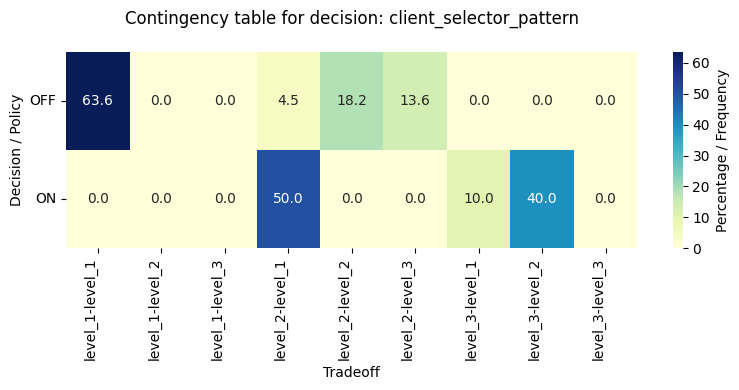

Analyzing Decision: message_compressor_pattern


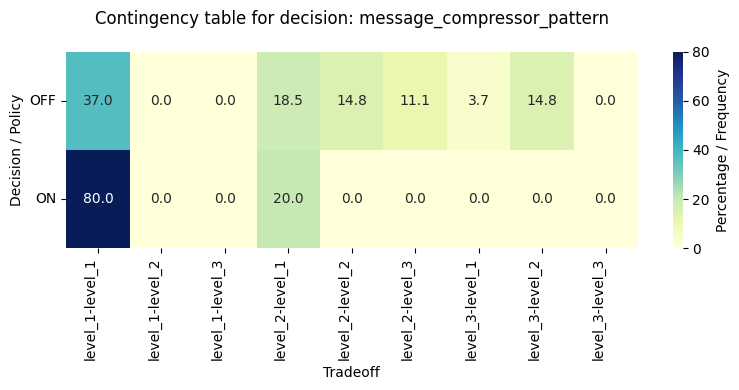

Analyzing Decision: hdh_pattern


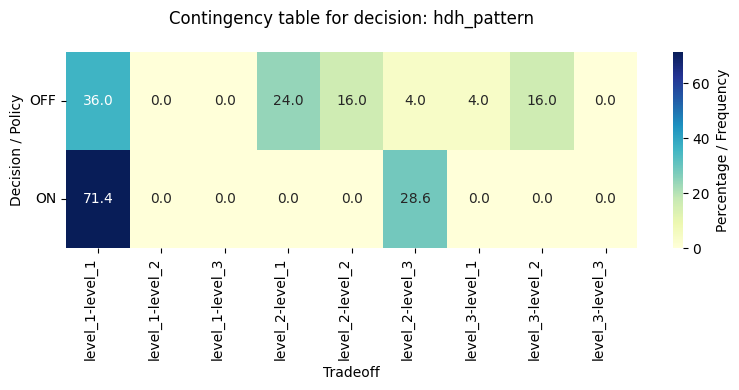

In [6]:
decisions = list(session.get_decisions().keys())
print("FL decisions:", decisions)

for decision_key in decisions:
    print(f"Analyzing Decision: {decision_key}")
    session.show_policy_contingency(
        decision_key,
        type='heatmap',
        subset='all',
        title=f"Contingency table for decision: {decision_key}",
        figsize=(8, 4)
    )
    plt.show()

In [7]:
print("Deterministic policies (policies that consistently result in a single specific tradeoff)")
for decision_key in decisions:
    print("---" * 10)
    print("Decision:", decision_key)
    for policy, tradeoff in session.get_deterministic_policies(decision_key):
        print("* Policy:", policy, "--> Tradeoff:", tradeoff)

Deterministic policies (policies that consistently result in a single specific tradeoff)
------------------------------
Decision: client_selector_pattern
------------------------------
Decision: message_compressor_pattern
------------------------------
Decision: hdh_pattern


In [8]:
print("Exclusive tradeoffs (tradeoffs reachable through only one decision's policy)")
for decision_key in decisions:
    print("---" * 10)
    print("Decision:", decision_key)
    for policy, tradeoff in session.get_exclusive_tradeoffs(decision_key):
        print("* Tradeoff:", tradeoff, "--> Decision:", decision_key, "[Policy:", policy, "]")

Exclusive tradeoffs (tradeoffs reachable through only one decision's policy)
------------------------------
Decision: client_selector_pattern
* Tradeoff: level_1-level_1 --> Decision: client_selector_pattern [Policy: OFF ]
* Tradeoff: level_2-level_2 --> Decision: client_selector_pattern [Policy: OFF ]
* Tradeoff: level_2-level_3 --> Decision: client_selector_pattern [Policy: OFF ]
* Tradeoff: level_3-level_1 --> Decision: client_selector_pattern [Policy: ON ]
* Tradeoff: level_3-level_2 --> Decision: client_selector_pattern [Policy: ON ]
------------------------------
Decision: message_compressor_pattern
* Tradeoff: level_2-level_2 --> Decision: message_compressor_pattern [Policy: OFF ]
* Tradeoff: level_2-level_3 --> Decision: message_compressor_pattern [Policy: OFF ]
* Tradeoff: level_3-level_1 --> Decision: message_compressor_pattern [Policy: OFF ]
* Tradeoff: level_3-level_2 --> Decision: message_compressor_pattern [Policy: OFF ]
------------------------------
Decision: hdh_patter

## 6. Feature Importance & Key-Parameter Selection (R6)

`compute_feature_scores` is called with `include_constraints=True` -- the R6
fix's call site (KTD3: no production code change was needed, only correct
notebook usage). This makes FL's 13 existing policy-bound pattern parameters
(Client Selector Strategy/Criteria/Value, Message Compressor Alg, and the 9
HDH parameters) participate in feature-importance scoring instead of being
silently dropped by the framework's `include_constraints=False` default.

In [9]:
scores_df = session.compute_feature_scores(
    use_smart_correlation=True,
    include_constraints=True,
    subset='train'
)
scores_df

Scoring features for outcome: best_val_f1 (on subset: train)
Original features (numeric only): ['Message Compressor Alg', 'CPU Mean', 'Client Selector Criteria', 'JSD Mean', 'Epochs', 'Learning Rate', 'HDH Latent Dim', 'HDH Learning Rate', 'HDH Batch Size', 'N Rounds', 'Batch Size', 'HDH Beta 2', 'Total Clients', 'Client Selector Value', 'HDH Epochs', 'Data Persistence Diversity', 'Alpha Dirichlet Mean', 'Data Distribution Diversity', 'HDH Generator', 'Client Selector Strategy', 'HDH Beta 1', 'RAM Mean', 'HDH Optimizer', 'HDH Discriminator']


Features selected: ['Message Compressor Alg', 'CPU Mean', 'Epochs', 'Learning Rate', 'N Rounds', 'Batch Size', 'HDH Beta 2', 'Total Clients', 'Data Persistence Diversity', 'Alpha Dirichlet Mean', 'Data Distribution Diversity', 'Client Selector Strategy', 'RAM Mean']
Scoring features for outcome: final_val_f1 (on subset: train)
Original features (numeric only): ['Message Compressor Alg', 'CPU Mean', 'Client Selector Criteria', 'JSD Mean', 'Epochs', 'Learning Rate', 'HDH Latent Dim', 'HDH Learning Rate', 'HDH Batch Size', 'N Rounds', 'Batch Size', 'HDH Beta 2', 'Total Clients', 'Client Selector Value', 'HDH Epochs', 'Data Persistence Diversity', 'Alpha Dirichlet Mean', 'Data Distribution Diversity', 'HDH Generator', 'Client Selector Strategy', 'HDH Beta 1', 'RAM Mean', 'HDH Optimizer', 'HDH Discriminator']


Features selected: ['Message Compressor Alg', 'CPU Mean', 'Epochs', 'Learning Rate', 'N Rounds', 'Batch Size', 'HDH Beta 2', 'Total Clients', 'Data Persistence Diversity', 'Alpha Dirichlet Mean', 'Data Distribution Diversity', 'Client Selector Strategy', 'RAM Mean']
Scoring features for outcome: final_val_accuracy (on subset: train)
Original features (numeric only): ['Message Compressor Alg', 'CPU Mean', 'Client Selector Criteria', 'JSD Mean', 'Epochs', 'Learning Rate', 'HDH Latent Dim', 'HDH Learning Rate', 'HDH Batch Size', 'N Rounds', 'Batch Size', 'HDH Beta 2', 'Total Clients', 'Client Selector Value', 'HDH Epochs', 'Data Persistence Diversity', 'Alpha Dirichlet Mean', 'Data Distribution Diversity', 'HDH Generator', 'Client Selector Strategy', 'HDH Beta 1', 'RAM Mean', 'HDH Optimizer', 'HDH Discriminator']


Features selected: ['Message Compressor Alg', 'CPU Mean', 'Epochs', 'Learning Rate', 'N Rounds', 'Batch Size', 'HDH Beta 2', 'Total Clients', 'Data Persistence Diversity', 'Alpha Dirichlet Mean', 'Data Distribution Diversity', 'Client Selector Strategy', 'RAM Mean']
Scoring features for outcome: avg_total_time (on subset: train)
Original features (numeric only): ['Message Compressor Alg', 'CPU Mean', 'Client Selector Criteria', 'JSD Mean', 'Epochs', 'Learning Rate', 'HDH Latent Dim', 'HDH Learning Rate', 'HDH Batch Size', 'N Rounds', 'Batch Size', 'HDH Beta 2', 'Total Clients', 'Client Selector Value', 'HDH Epochs', 'Data Persistence Diversity', 'Alpha Dirichlet Mean', 'Data Distribution Diversity', 'HDH Generator', 'Client Selector Strategy', 'HDH Beta 1', 'RAM Mean', 'HDH Optimizer', 'HDH Discriminator']


Features selected: ['Message Compressor Alg', 'CPU Mean', 'Epochs', 'Learning Rate', 'N Rounds', 'Batch Size', 'HDH Beta 2', 'Total Clients', 'Data Persistence Diversity', 'Alpha Dirichlet Mean', 'Data Distribution Diversity', 'Client Selector Strategy', 'RAM Mean']
Scoring features for outcome: avg_training_time (on subset: train)
Original features (numeric only): ['Message Compressor Alg', 'CPU Mean', 'Client Selector Criteria', 'JSD Mean', 'Epochs', 'Learning Rate', 'HDH Latent Dim', 'HDH Learning Rate', 'HDH Batch Size', 'N Rounds', 'Batch Size', 'HDH Beta 2', 'Total Clients', 'Client Selector Value', 'HDH Epochs', 'Data Persistence Diversity', 'Alpha Dirichlet Mean', 'Data Distribution Diversity', 'HDH Generator', 'Client Selector Strategy', 'HDH Beta 1', 'RAM Mean', 'HDH Optimizer', 'HDH Discriminator']


Features selected: ['Message Compressor Alg', 'CPU Mean', 'Epochs', 'Learning Rate', 'N Rounds', 'Batch Size', 'HDH Beta 2', 'Total Clients', 'Data Persistence Diversity', 'Alpha Dirichlet Mean', 'Data Distribution Diversity', 'Client Selector Strategy', 'RAM Mean']
Scoring features for outcome: avg_communication_time (on subset: train)
Original features (numeric only): ['Message Compressor Alg', 'CPU Mean', 'Client Selector Criteria', 'JSD Mean', 'Epochs', 'Learning Rate', 'HDH Latent Dim', 'HDH Learning Rate', 'HDH Batch Size', 'N Rounds', 'Batch Size', 'HDH Beta 2', 'Total Clients', 'Client Selector Value', 'HDH Epochs', 'Data Persistence Diversity', 'Alpha Dirichlet Mean', 'Data Distribution Diversity', 'HDH Generator', 'Client Selector Strategy', 'HDH Beta 1', 'RAM Mean', 'HDH Optimizer', 'HDH Discriminator']


Features selected: ['Message Compressor Alg', 'CPU Mean', 'Epochs', 'Learning Rate', 'N Rounds', 'Batch Size', 'HDH Beta 2', 'Total Clients', 'Data Persistence Diversity', 'Alpha Dirichlet Mean', 'Data Distribution Diversity', 'Client Selector Strategy', 'RAM Mean']
Scoring features for outcome: CPU Usage Avg Mean (on subset: train)
Original features (numeric only): ['Message Compressor Alg', 'CPU Mean', 'Client Selector Criteria', 'JSD Mean', 'Epochs', 'Learning Rate', 'HDH Latent Dim', 'HDH Learning Rate', 'HDH Batch Size', 'N Rounds', 'Batch Size', 'HDH Beta 2', 'Total Clients', 'Client Selector Value', 'HDH Epochs', 'Data Persistence Diversity', 'Alpha Dirichlet Mean', 'Data Distribution Diversity', 'HDH Generator', 'Client Selector Strategy', 'HDH Beta 1', 'RAM Mean', 'HDH Optimizer', 'HDH Discriminator']


Features selected: ['Message Compressor Alg', 'CPU Mean', 'Epochs', 'Learning Rate', 'N Rounds', 'Batch Size', 'HDH Beta 2', 'Total Clients', 'Data Persistence Diversity', 'Alpha Dirichlet Mean', 'Data Distribution Diversity', 'Client Selector Strategy', 'RAM Mean']
Scoring features for outcome: RAM Usage Avg Mean (on subset: train)
Original features (numeric only): ['Message Compressor Alg', 'CPU Mean', 'Client Selector Criteria', 'JSD Mean', 'Epochs', 'Learning Rate', 'HDH Latent Dim', 'HDH Learning Rate', 'HDH Batch Size', 'N Rounds', 'Batch Size', 'HDH Beta 2', 'Total Clients', 'Client Selector Value', 'HDH Epochs', 'Data Persistence Diversity', 'Alpha Dirichlet Mean', 'Data Distribution Diversity', 'HDH Generator', 'Client Selector Strategy', 'HDH Beta 1', 'RAM Mean', 'HDH Optimizer', 'HDH Discriminator']


Features selected: ['Message Compressor Alg', 'CPU Mean', 'Epochs', 'Learning Rate', 'N Rounds', 'Batch Size', 'HDH Beta 2', 'Total Clients', 'Data Persistence Diversity', 'Alpha Dirichlet Mean', 'Data Distribution Diversity', 'Client Selector Strategy', 'RAM Mean']


,best_val_f1,final_val_f1,final_val_accuracy,avg_total_time,avg_training_time,avg_communication_time,CPU Usage Avg Mean,RAM Usage Avg Mean
Alpha Dirichlet Mean,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
Batch Size,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
CPU Mean,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
Client Selector Criteria,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
Client Selector Strategy,0.314190,0.301943,0.261473,0.207885,0.191877,0.216091,0.477157,1.928276e-15
Client Selector Value,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
Data Distribution Diversity,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
Data Persistence Diversity,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
Epochs,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
HDH Batch Size,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00


### R6 regression guard

All 13 of FL's existing pattern parameters must appear in the
feature-importance ranking output. If a future edit reintroduces the
`include_constraints=False` default at this call site, this assertion -- not
silent output -- is what fails `nbconvert --execute`.

In [10]:
FL_PATTERN_PARAMETERS = [
    "Client Selector Strategy", "Client Selector Criteria", "Client Selector Value",
    "Message Compressor Alg",
    "HDH Batch Size", "HDH Beta 1", "HDH Beta 2", "HDH Discriminator", "HDH Epochs",
    "HDH Generator", "HDH Learning Rate", "HDH Latent Dim", "HDH Optimizer",
]
assert len(FL_PATTERN_PARAMETERS) == 13

missing = [p for p in FL_PATTERN_PARAMETERS if p not in scores_df.index]
assert not missing, (
    f"compute_feature_scores(include_constraints=True) dropped pattern parameters: {missing}"
)
print(f"All {len(FL_PATTERN_PARAMETERS)} FL pattern parameters are present "
      f"in the feature-importance ranking (R6 verified).")

All 13 FL pattern parameters are present in the feature-importance ranking (R6 verified).


In [11]:
weighted_features = session.get_weighted_feature_ranking(scores_df)
print("Weighted feature ranking:", weighted_features)

key_parameters_raw = session.select_top_k_parameters(
    scores_df, index_order=weighted_features, threshold=0.2, k=None
)
print("Top-ranked parameters (unfiltered):", key_parameters_raw)

# Restrict scenario-discovery parameters to genuinely numeric-dtype columns.
#
# Pre-existing framework limitation, independent of KTD8's analyzer_fi bug and
# out of scope for U4's one-line session.py fix: discover_scenarios(standardize=True)
# fits its StandardScaler on the *sentinel-transformed* training slice
# (FeatureImportanceAnalyzer.preprocess_features applies SemanticNaNHandler's
# sentinel transformation first), but then transforms the *raw, untransformed*
# test slice through that same fitted scaler. For an optional CATEGORICAL
# constraint parameter (e.g. 'Message Compressor Alg'), the sentinel transform
# collapses it to a numeric 0/1 "was this selected" presence flag in the
# training data -- but the raw test slice still holds the original string
# values ('zlib', etc.), and scaler.transform() raises
# `ValueError: could not convert string to float` when it hits them. Numeric
# optional parameters (e.g. 'JSD Mean') are unaffected: their raw NaNs simply
# propagate as NaN through the arithmetic instead of raising. We work around
# this here, at the notebook call site, by only passing numeric-dtype
# parameters into scenario discovery.
key_parameters = [
    p for p in key_parameters_raw
    if pd.api.types.is_numeric_dtype(session.experiments_df[p])
]
if not key_parameters:
    # Fallback: if top-k filtering left nothing numeric, use the numeric subset
    # of all scored parameters rather than calling discover_scenarios with an
    # empty parameter list.
    key_parameters = [
        p for p in scores_df.index
        if pd.api.types.is_numeric_dtype(session.experiments_df[p])
    ]

print("Key parameters (for scenario discovery):", key_parameters)

Weighted feature ranking: ['HDH Beta 2', 'Message Compressor Alg', 'Client Selector Strategy']
Top-ranked parameters (unfiltered): ['HDH Beta 2', 'Message Compressor Alg', 'Client Selector Strategy']
Key parameters (for scenario discovery): ['HDH Beta 2']


## 7. Scenario Discovery: PRIM (R9)

KTD8's `analyzer_fi` -> `analyzer` fix in `_discover_single_prim`
(`adept/core/session.py`) is required for this cell to run at all: with
`standardize=True`, the unfixed method referenced the undefined name
`analyzer_fi` and raised `NameError` before computing any box.

In [12]:
prim_boxes = []
non_empty_tradeoffs = session.get_tradeoffs(non_empty=True)
for tradeoff in non_empty_tradeoffs:
    print("---" * 10)
    print(f"Discovering scenarios for: {tradeoff.name}")
    boxes = session.discover_scenarios(
        tradeoff.name, method='prim',
        threshold=0.8,
        standardize=True,
        parameters=key_parameters
    )
    non_empty_boxes = [b for b in boxes if not b.is_empty()]
    if non_empty_boxes:
        best_box = non_empty_boxes[0]
        print(f"* Key Rules: {best_box.limits}")
        print(f"* Metrics: {best_box.metrics}")
        prim_boxes.append(best_box)
    else:
        print("--> No scenarios discovered.")

print(f"\n{len(prim_boxes)} non-empty PRIM box(es) discovered across "
      f"{len(non_empty_tradeoffs)} non-empty tradeoffs.")

------------------------------
Discovering scenarios for: level_1-level_1
Running PRIM discovery for: level_1-level_1 ...
Instances satisfying property: True     11
False    11
Name: count, dtype: int64
Total instances: (22, 1)
Running PRIM ... rhodium
2 possible boxes
* Key Rules: {'HDH Beta 2': {'min': 0.94905, 'max': 0.999}}
* Metrics: {'density': 0.5, 'coverage': 0.3333333333333333, 'population_prevalence': 0.5, 'lift': 0.0, 'samples_in_box': 2.0, 'targets_in_box': 1.0}
------------------------------
Discovering scenarios for: level_2-level_1
Running PRIM discovery for: level_2-level_1 ...
Instances satisfying property: False    19
True      3
Name: count, dtype: int64
Total instances: (22, 1)
Running PRIM ... rhodium
2 possible boxes
--> No scenarios discovered.
------------------------------
Discovering scenarios for: level_2-level_2
Running PRIM discovery for: level_2-level_2 ...
Instances satisfying property: False    19
True      3
Name: count, dtype: int64
Total instances: (2

/Users/adiazpace/opt/anaconda3/envs/perfmodels/lib/python3.11/site-packages/prim/prim_box.py:415: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.peeling_trajectory = pd.concat([self.peeling_trajectory, pd.DataFrame([stats])],
/Users/adiazpace/opt/anaconda3/envs/perfmodels/lib/python3.11/site-packages/prim/prim_box.py:415: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.peeling_trajectory = pd.concat([self.peeling_trajectory, pd.DataFrame([stats])],
/Users/adiazpace/opt/anaconda3/envs/perf

## 8. Global Discovery: CART (R9)

Using decision trees, we partition the entire design space into regions,
providing a global map of the most likely outcomes for any input
combination.

In [13]:
cart_boxes_all = session.discover_scenarios(method='cart', standardize=True, parameters=key_parameters)
cart_boxes = []
for idx, box in enumerate(cart_boxes_all):
    if not box.is_empty():
        lift = box.metrics.get('lift', None)
        lift_str = f"{lift:.2f}" if lift is not None else "n/a"
        print(f" {idx+1}. For tradeoff {box.target_tradeoff} ({box.target_tradeoff_labels}): "
              f"lift={lift_str} \n\t{box.limits}")
        cart_boxes.append(box)
    else:
        solutions = box.metrics.get('targets_in_box', 0)
        print(f" Skipping empty box. For tradeoff {box.target_tradeoff} "
              f"({box.target_tradeoff_labels}) {solutions}")

print(f"\n{len(cart_boxes)} non-empty CART box(es) discovered.")

Running CART global discovery for all tradeoff combinations ...
 Skipping empty box. For tradeoff level_1-level_1 (level_1,level_1,level_1,level_1,level_1,level_2,level_1,level_1) 0.0
 2. For tradeoff level_1-level_1 (level_1,level_1,level_1,level_1,level_1,level_1,level_1,level_3): lift=0.36 
	{'HDH Beta 2': {'min': 0.9490587342157559, 'max': 0.999}}

1 non-empty CART box(es) discovered.


## 9. Box Diagnostics (R9) and Best-Effort N/A-Hatching Check (R10)

We first visualize the first non-empty discovered box (PRIM or CART). We then
search all discovered boxes for one whose limits, for some optional
parameter, include that parameter's sentinel "not selected" value -- the
condition that exercises the box-diagnostics N/A-hatching render path (R10).

Each FL pattern is ON in only 5-10 of 32 rows, so PRIM/CART peeling toward the
in-distribution ("selected") region may not naturally produce such a box; if
it doesn't, we report that explicitly below rather than asserting one exists
or silently doing nothing (per R10's documented "reportable outcome, not a
plan failure").

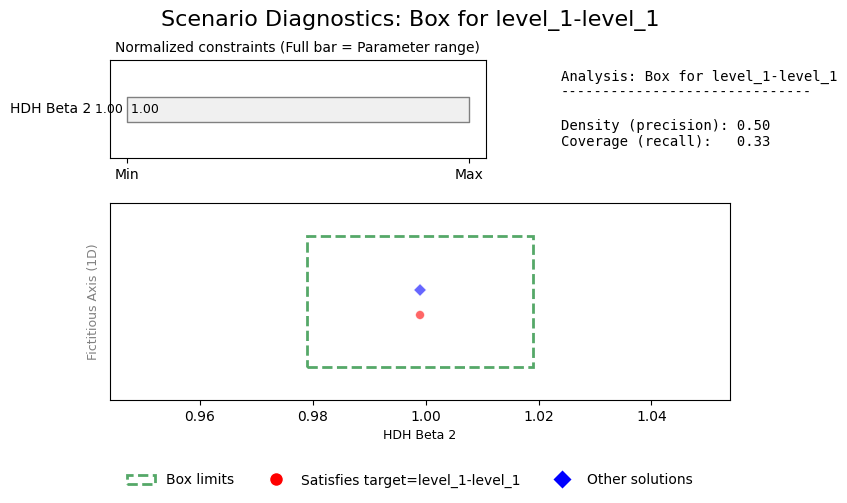

In [14]:
all_boxes = prim_boxes + cart_boxes

if all_boxes:
    first_box = all_boxes[0]
    fig = session.show_box_diagnostics(box=first_box, subset='test', show_policies=False, figsize=(8, 5))
    plt.show()
else:
    print("No non-empty boxes were discovered by PRIM or CART; skipping box diagnostics.")

In [15]:
# Compute the sentinel value assigned to each optional parameter's "not selected"
# state -- the same sentinel-transformation logic scenario discovery uses
# internally (KTD5 / SemanticNaNHandler.apply_sentinel_transformation).
all_param_objs = []
for comp in session.sys_def.system.components.values():
    all_param_objs.extend(comp.parameters.values())
all_param_objs.extend(session.sys_def.system.parameters.values())

_, sentinels = SemanticNaNHandler.apply_sentinel_transformation(session.experiments_df, all_param_objs)
print("Sentinel ('not selected') values for optional parameters:", sentinels)

na_hatching_box = None
for box in all_boxes:
    for param_name, limits in box.limits.items():
        sentinel = sentinels.get(param_name)
        if sentinel is not None and limits['min'] <= sentinel <= limits['max']:
            na_hatching_box = (box, param_name)
            break
    if na_hatching_box:
        break

if na_hatching_box:
    box, param_name = na_hatching_box
    print(f"R10: found a box whose limits for '{param_name}' include its 'not selected' "
          f"sentinel ({sentinels[param_name]:.4f}). Rendering N/A-hatching diagnostics:")
    fig = session.show_box_diagnostics(box=box, subset='test', show_policies=False, figsize=(8, 5))
    plt.show()
else:
    print("R10: no PRIM/CART box discovered in this run has limits that include an optional "
          "parameter's 'not selected' sentinel state. This is a plausible, reportable outcome "
          "(not a failure) given each FL pattern is ON in only 5-10 of 32 rows -- PRIM/CART "
          "peeling naturally converges toward the in-distribution ('selected') region rather "
          "than the sparse NaN/sentinel region. No N/A-hatching box is rendered in this run.")

Sentinel ('not selected') values for optional parameters: {'Client Selector Strategy': 0.0, 'Client Selector Criteria': 0.0, 'Client Selector Value': 1.8, 'Message Compressor Alg': 0.0, 'HDH Batch Size': 28.8, 'HDH Beta 1': 0.45, 'HDH Beta 2': 0.8991, 'HDH Discriminator': 0.0, 'HDH Epochs': 0.9, 'HDH Generator': 0.0, 'HDH Learning Rate': 0.00018, 'HDH Latent Dim': 90.0, 'HDH Optimizer': 0.0, 'JSD Mean': 0.1277999999999999}
R10: no PRIM/CART box discovered in this run has limits that include an optional parameter's 'not selected' sentinel state. This is a plausible, reportable outcome (not a failure) given each FL pattern is ON in only 5-10 of 32 rows -- PRIM/CART peeling naturally converges toward the in-distribution ('selected') region rather than the sparse NaN/sentinel region. No N/A-hatching box is rendered in this run.


## 10. Notebook Status (R11)

This notebook is now the canonical validation path for the Federated Learning
example, exercising the framework's real methodology end to end: model
summary (R4), spec linting (R1-R3), tradeoff definition, per-decision
contingency analysis, key-parameter selection with FL's policy-bound pattern
parameters included (R6), PRIM/CART scenario discovery, and box diagnostics
including a best-effort N/A-hatching check (R9/R10).

`federatedlearning/test_manual_simple.py`, `federatedlearning/test_nan_feature.ipynb`,
and the root `test_nan_manual.py` are retired as the primary validation path
(R11). They remain in place -- unmodified, not deleted -- but should no
longer be treated as the authoritative way to validate FL support; use this
notebook instead.